In [1]:
import zipfile
import os

zip_path = "/content/dataset_split.zip"   # change this
extract_path = "/content/dataset_split"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully!")

✅ Unzipped successfully!


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

train_dir = "dataset_split/train"
val_dir = "dataset_split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# DATA LOADER
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# BASE MODEL
base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base_model.trainable = False

# MODEL HEAD
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop]
)

Found 53 images belonging to 3 classes.
Found 16 images belonging to 3 classes.
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 37s 17s/step - accuracy: 0.3962 - loss: 1.1042 - val_accuracy: 0.3125 - val_loss: 1.1330
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4151 - loss: 1.0926 - val_accuracy: 0.3125 - val_loss: 1.1202
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.3962 - loss: 1.1201 - val_accuracy: 0.3125 - val_loss: 1.1201
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.3208 - loss: 1.1485 - val_accuracy: 0.3750 - val_loss: 1.0833
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.3962 - loss: 1.1190 - val_accuracy: 0.3750 - val_loss: 1.0804
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.3208 - loss: 1.1177 - val_accuracy: 0.3750 - val_loss: 1.0971
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.3019 - loss: 1.2431 - val_accuracy: 0.3125 - val_loss: 1.1150


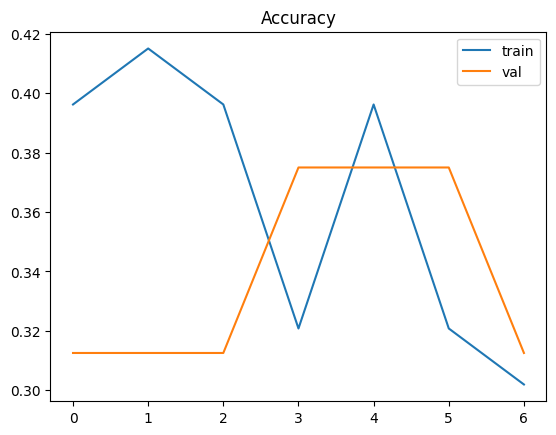

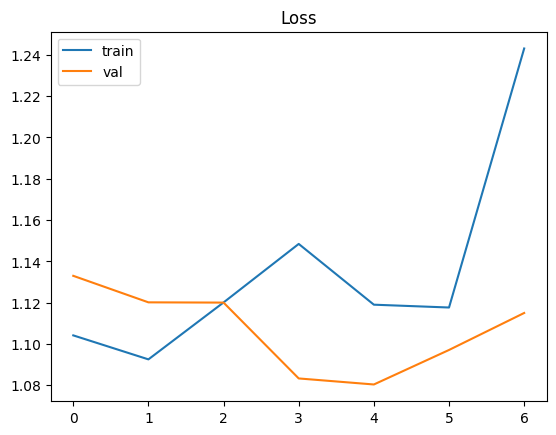

In [6]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(val_data.classes, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.38      1.00      0.55         6
           2       0.00      0.00      0.00         5

    accuracy                           0.38        16
   macro avg       0.12      0.33      0.18        16
weighted avg       0.14      0.38      0.20        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.3750 - loss: 1.0804
Validation Accuracy: 0.375
